# California Housing (PySpark DataFrames API) — Linear Regression + Bucketed Logistic Regression

This notebook shows an example solution using **PySpark DataFrames + MLlib Pipelines** (no NumPy / pandas).

You will:
1. Read the California Housing dataset directly from **Google Cloud Storage (GCS)** (`gs://...`).
2. Train a **Linear Regression** pipeline to predict `medhouseprice`.
3. Analyze `medhouseprice` distribution and convert it into **3 buckets**: `low`, `med`, `high`.
4. Train a **Multinomial Logistic Regression** pipeline to predict those buckets.

> Notes  
> - Reading from `gs://...` typically works out-of-the-box on **Dataproc** and many managed Spark environments.  
> - If you're running on a self-managed Spark cluster, ensure the GCS connector and credentials are configured.


In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("week9-lr").getOrCreate()
print("Spark version:", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/04 04:21:15 INFO SparkEnv: Registering MapOutputTracker
26/03/04 04:21:15 INFO SparkEnv: Registering BlockManagerMaster
26/03/04 04:21:15 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
26/03/04 04:21:16 INFO SparkEnv: Registering OutputCommitCoordinator


Spark version: 3.5.3


## 1) Read from Google Cloud Storage


In [2]:
GCS_URI = "gs://bucket-5460/california.csv"

df_raw = (spark.read
        .option("header", True)
        .option("inferSchema", True)
        .option("mode", "DROPMALFORMED")
        .csv(GCS_URI)
    )

df_raw.cache()
print("Rows:", df_raw.count())
print("Columns:", len(df_raw.columns))
df_raw.printSchema()
df_raw.show(5, truncate=False)

Rows: 20640
Columns: 9
root
 |-- MedInc: double (nullable = true)
 |-- HouseAge: double (nullable = true)
 |-- AveRooms: double (nullable = true)
 |-- AveBedrms: double (nullable = true)
 |-- Population: double (nullable = true)
 |-- AveOccup: double (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- MedHouseVal: double (nullable = true)

+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+
|MedInc|HouseAge|AveRooms          |AveBedrms         |Population|AveOccup          |Latitude|Longitude|MedHouseVal|
+------+--------+------------------+------------------+----------+------------------+--------+---------+-----------+
|8.3252|41.0    |6.984126984126984 |1.0238095238095237|322.0     |2.5555555555555554|37.88   |-122.23  |4.526      |
|8.3014|21.0    |6.238137082601054 |0.9718804920913884|2401.0    |2.109841827768014 |37.86   |-122.22  |3.585      |
|7.2574|52.0    |8.28

## 2) Basic cleaning + column normalization

- normalize column names (lowercase, underscores)
- detect and standardize the label column to `medhouseprice`
- cast numeric columns to `double`
- drop rows with null label


In [4]:
from pyspark.sql import functions as F
from pyspark.sql import types as T

label_col = 'MedHouseVal'

# Drop rows with null label (can't train without label)
df = df_raw.filter(F.col(label_col).isNotNull())

print("After cleaning: rows =", df.count())
df.select(label_col).summary("count","mean","stddev","min","25%","50%","75%","max").show(truncate=False)

num_cols = [c for c in df.columns if c != label_col]

After cleaning: rows = 20640
+-------+------------------+
|summary|MedHouseVal       |
+-------+------------------+
|count  |20640             |
|mean   |2.0685581690891843|
|stddev |1.1539561587441398|
|min    |0.14999           |
|25%    |1.196             |
|50%    |1.797             |
|75%    |2.647             |
|max    |5.00001           |
+-------+------------------+



## 3) Linear Regression Pipeline

Our pipeline includes:
- Numeric: shows the `Imputer(strategy="median")` as an example, but our data really doesn't have missing data
- Assemble into a single `features` vector
- Scale features with `StandardScaler`
- Linear Regression model


In [10]:
from pyspark.ml.feature import Imputer, StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Train/test split
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)
print("Train rows:", train_df.count(), " Test rows:", test_df.count())

# --- Preprocessing stages ---
stages = []

# Numeric imputation
num_imputed_cols = [c + "_imputed" for c in num_cols]
if len(num_cols) > 0:
    imputer = Imputer(inputCols=num_cols, outputCols=num_imputed_cols, strategy="median")
    stages.append(imputer)
else:
    num_imputed_cols = []

# Assemble
assembler = VectorAssembler(inputCols=num_imputed_cols, outputCol="features_raw", handleInvalid="keep")
stages.append(assembler)

# Scale
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)
stages.append(scaler)

# Linear Regression model
lr = LinearRegression(
    featuresCol="features",
    labelCol=label_col,
    predictionCol="prediction",
    maxIter=200
)
stages.append(lr)

lr_pipeline = Pipeline(stages=stages)

# Fit + predict
lr_model = lr_pipeline.fit(train_df)
lr_preds = lr_model.transform(test_df)

lr_preds.select(label_col, "prediction").show(10, truncate=False)

# Evaluate
rmse = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="rmse").evaluate(lr_preds)
mae  = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="mse").evaluate(lr_preds)
r2   = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="r2").evaluate(lr_preds)

print(f"Test RMSE = {rmse:.4f}")
print(f"Test MSE  = {mae:.4f}")
print(f"Test R2   = {r2:.4f}")

Train rows: 16560  Test rows: 4080


26/03/04 04:32:33 WARN Instrumentation: [b789bf54] regParam is zero, which might cause numerical instability and overfitting.


+-----------+------------------+
|MedHouseVal|prediction        |
+-----------+------------------+
|0.735      |1.731251484173518 |
|1.625      |0.8865069076847218|
|0.675      |1.0951342796910501|
|1.625      |1.2032679196447753|
|0.875      |0.9787314173906367|
|1.113      |0.8442467467077788|
|1.344      |0.9912827617493591|
|1.042      |1.0931510811202487|
|0.818      |1.146509008595905 |
|1.531      |0.7325861818189849|
+-----------+------------------+
only showing top 10 rows

Test RMSE = 0.7188
Test MSE  = 0.5167
Test R2   = 0.6113


## 4) Inspect linear regression coefficients

We attempt to extract feature names from Spark's vector metadata. 
If metadata isn't available, we fall back to positional feature indices.


In [13]:
from pyspark.sql import functions as F

lr_stage = lr_model.stages[-1]

print("Intercept:", float(lr_stage.intercept))
print("Num coefficients:", len(lr_stage.coefficients))

# Find assembler stage
assembler_stage = None
for stage in lr_model.stages:
    if stage.__class__.__name__ == "VectorAssembler":
        assembler_stage = stage
        break

feature_names = assembler_stage.getInputCols()

# Cast coefficients to native Python float
coef_values = [float(c) for c in lr_stage.coefficients]

coef_rows = list(zip(feature_names, coef_values))

coef_df = spark.createDataFrame(coef_rows, ["feature", "coefficient"])

coef_df = coef_df.withColumn("abs_coeff", F.abs(F.col("coefficient")))

coef_df.orderBy(F.desc("abs_coeff")).show(25, truncate=False)

Intercept: 2.0643239577293557
Num coefficients: 8


+------------------+---------------------+--------------------+
|feature           |coefficient          |abs_coeff           |
+------------------+---------------------+--------------------+
|Latitude_imputed  |-0.9027288474604621  |0.9027288474604621  |
|Longitude_imputed |-0.8721943903924714  |0.8721943903924714  |
|MedInc_imputed    |0.8238967939090207   |0.8238967939090207  |
|AveBedrms_imputed |0.2978148646301612   |0.2978148646301612  |
|AveRooms_imputed  |-0.2553871615841757  |0.2553871615841757  |
|HouseAge_imputed  |0.12013798371556401  |0.12013798371556401 |
|AveOccup_imputed  |-0.0401903233129275  |0.0401903233129275  |
|Population_imputed|-0.004204571089370543|0.004204571089370543|
+------------------+---------------------+--------------------+



## 5) Analyze `MedHouseVal` distribution and create 3 buckets (low/med/high)

We'll use **approximate quantiles** to choose cut points at the 33rd and 66th percentiles, then bucketize:
- `low`  : `MedHouseVal` ≤ p33
- `med`  : p33 < `MedHouseVal` ≤ p66
- `high` : `MedHouseVal` > p66


In [14]:
# Quantile analysis
p33, p66 = df.approxQuantile(label_col, [0.33, 0.66], 0.01)
minv, maxv = df.agg(F.min(label_col).alias("min"), F.max(label_col).alias("max")).first()

print(f"{label_col} min = {minv}, max = {maxv}")
print(f"Approx p33 = {p33}")
print(f"Approx p66 = {p66}")

# Bucket into low/med/high (string labels)
df_bucketed = (
    df.withColumn(
        "price_bucket",
        F.when(F.col(label_col) <= F.lit(p33), F.lit("low"))
         .when(F.col(label_col) <= F.lit(p66), F.lit("med"))
         .otherwise(F.lit("high"))
    )
)

df_bucketed.groupBy("price_bucket").count().orderBy("price_bucket").show()

# Peek at label vs bucket
df_bucketed.select(label_col, "price_bucket").orderBy(F.col(label_col)).show(20, truncate=False)

MedHouseVal min = 0.14999, max = 5.00001
Approx p33 = 1.388
Approx p66 = 2.259
+------------+-----+
|price_bucket|count|
+------------+-----+
|        high| 7143|
|         low| 6662|
|         med| 6835|
+------------+-----+

+-----------+------------+
|MedHouseVal|price_bucket|
+-----------+------------+
|0.14999    |low         |
|0.14999    |low         |
|0.14999    |low         |
|0.14999    |low         |
|0.175      |low         |
|0.225      |low         |
|0.225      |low         |
|0.225      |low         |
|0.225      |low         |
|0.25       |low         |
|0.266      |low         |
|0.269      |low         |
|0.275      |low         |
|0.283      |low         |
|0.3        |low         |
|0.3        |low         |
|0.325      |low         |
|0.325      |low         |
|0.325      |low         |
|0.325      |low         |
+-----------+------------+
only showing top 20 rows



## 6) Logistic Regression pipeline (predict bucketed price class)

We will fit a **multiclass (3-class) logistic regression** with `family="multinomial"`.

Pipeline steps:
1. `StringIndexer` on `price_bucket` → numeric `label`
2. Same preprocessing as regression (impute, encode categoricals, assemble, scale)
3. `LogisticRegression` classifier


In [19]:
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler, IndexToString

# Train / Test Split
train_c, test_c = df_bucketed.randomSplit([0.8, 0.2], seed=42)
print("Train rows:", train_c.count(), " Test rows:", test_c.count())

# Label Indexer (string → numeric)
label_indexer = StringIndexer(inputCol="price_bucket", outputCol="label", handleInvalid="error")

# Feature Assembler
assembler_c = VectorAssembler(inputCols=num_cols, outputCol="features_raw", handleInvalid="keep")

# Scaling
scaler_c = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)

# Multiclass Logistic Regression
logreg = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    probabilityCol="probability",
    maxIter=200,
    family="multinomial",
    regParam=0.1,           # adding regularization here
    elasticNetParam=0.0
)

# Build Pipeline
stages_c = [label_indexer, assembler_c, scaler_c, logreg]

cls_pipeline = Pipeline(stages=stages_c)

# Fit + Predict
cls_model = cls_pipeline.fit(train_c)
cls_preds = cls_model.transform(test_c)

cls_preds.select(
    "price_bucket", "label", "prediction", "probability"
).show(10, truncate=False)

# Evaluation
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

acc = evaluator.setMetricName("accuracy").evaluate(cls_preds)
f1  = evaluator.setMetricName("f1").evaluate(cls_preds)

print(f"Test Accuracy = {acc:.4f}")
print(f"Test F1       = {f1:.4f}")

# -----------------------------
# Convert numeric prediction back to string
# -----------------------------
label_model = cls_model.stages[0]  # StringIndexerModel
to_str = IndexToString(
    inputCol="prediction",
    outputCol="predicted_bucket",
    labels=label_model.labels
)

cls_preds_labeled = to_str.transform(cls_preds)

# Confusion Matrix
labels = label_model.labels

conf_matrix = (
    cls_preds_labeled
        .groupBy("price_bucket")
        .pivot("predicted_bucket", labels)
        .count()
        .na.fill(0)
        .orderBy("price_bucket")
)

conf_matrix.show()

# Show mistakes
(
    cls_preds_labeled
    .filter(F.col("price_bucket") != F.col("predicted_bucket"))
    .select("price_bucket", "predicted_bucket", "probability")
    .show(20, truncate=False)
)

Train rows: 16560  Test rows: 4080
+------------+-----+----------+------------------------------------------------------------+
|price_bucket|label|prediction|probability                                                 |
+------------+-----+----------+------------------------------------------------------------+
|low         |2.0  |2.0       |[0.04048716290010142,0.1149796352636507,0.8445332018362479] |
|med         |1.0  |2.0       |[0.06943813273512414,0.30319105583700545,0.6273708114278704]|
|low         |2.0  |2.0       |[0.08699797553612898,0.22289937655249117,0.6901026479113798]|
|med         |1.0  |2.0       |[0.03225793904233768,0.1907139660314044,0.777028094926258]  |
|low         |2.0  |2.0       |[0.07899766731528925,0.20758512914557534,0.7134172035391353]|
|low         |2.0  |2.0       |[0.06496530707978013,0.3407912905215765,0.5942434023986434] |
|low         |2.0  |2.0       |[0.07640430875447353,0.34888134061939424,0.5747143506261321]|
|low         |2.0  |2.0       |[0.0

## 7) (Optional) Inspect logistic regression parameters

For multiclass logistic regression, Spark provides a coefficient matrix (one row per class).


In [20]:
logreg_stage = cls_model.stages[-1]  # LogisticRegressionModel
print("Num classes:", logreg_stage.numClasses)
print("Num features:", logreg_stage.numFeatures)
print("Intercept vector length:", len(logreg_stage.interceptVector))
print("Coefficient matrix size:", logreg_stage.coefficientMatrix.numRows, "x", logreg_stage.coefficientMatrix.numCols)

Num classes: 3
Num features: 8
Intercept vector length: 3
Coefficient matrix size: 3 x 8


## Summary

What we did:
- A **Linear Regression** pipeline predicting `MedHouseVal`
- A bucketed target (`low/med/high`) built from quantile analysis
- A **Multinomial Logistic Regression** pipeline predicting that bucket

If you want to persist models:
- `lr_model.write().overwrite().save("...")`
- `cls_model.write().overwrite().save("...")`

(Where the path is a distributed filesystem path, e.g., `gs://...`)


## Some Additional Notes on Working with ML on Big Data:
### Key pattern: Spark -> Small result -> collect -> plot
- Spark is for distributed compute (scan/filter/join/groupBy/window, etc.)
    - Only `collect` what you can fit + plot (aggregations, top‑k, samples, sketches)
    - Use Spark for heavy lifting: groupBy, agg, windows, bucketing, joins
    
- pandas / numpy / matplotlib (and plotly) are single-machine tools, so they should be used after you’ve reduced the data to something that:
    - fits comfortably in driver memory, and
    - is actually meaningful to visualize (not a million overlapping dots)
    

### What “EDA at scale” usually looks like:
- Distributions: histogram bins / approximate quantiles computed in Spark, then plot
- Aggregations (groupBy + top‑k): counts/means/rates by time/category/segment
- 2D structure: sampling (often stratified) or 2D density (hexbin/heatmap from Spark counts)
- Cohorts/funnels/retention: naturally aggregated
- Anomaly/drift: plot metric summaries (mean/std/missing/p95) over time
- Approx algorithms: approx quantiles/distinct/frequent items when exact is too expensive
- **Avoid** plotting millions of raw points 
- **Avoid** pulling large tables into pandas for “classic” EDA

### General rule of thumb:
- If the plot needs ≤ ~10k–100k points (depending on plot type) or ≤ a few thousand bins/groups, you’re good.
- If it needs raw rows beyond that, redesign as aggregation, sample, or sketch.

26/03/04 16:03:10 WARN Instrumentation: [5c030ead] regParam is zero, which might cause numerical instability and overfitting.


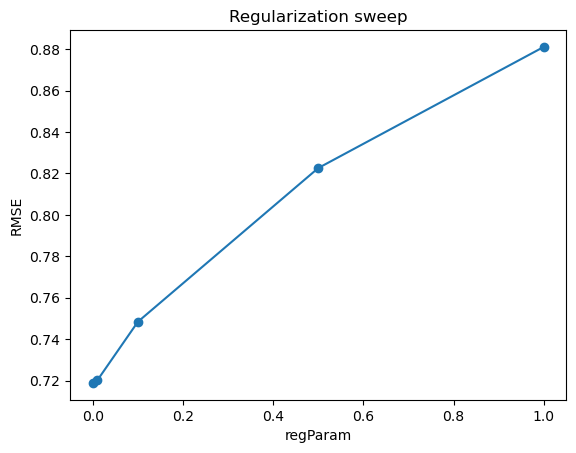

In [21]:
import matplotlib.pyplot as plt
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

reg_params = [0.0, 0.01, 0.1, 0.5, 1.0]
rmse_points = []

for rp in reg_params:
    lr = LinearRegression(featuresCol="features", labelCol=label_col, regParam=rp, maxIter=200)
    pipe = Pipeline(stages=stages[:-1] + [lr])  # reuse same preprocessing, swap estimator
    
    model = pipe.fit(train_df)
    preds = model.transform(test_df)

    rmse = RegressionEvaluator(labelCol=label_col, predictionCol="prediction", metricName="rmse").evaluate(preds)
    rmse_points.append(float(rmse))

plt.figure()
plt.plot(reg_params, rmse_points, marker="o")
plt.title("Regularization sweep")
plt.xlabel("regParam")
plt.ylabel("RMSE")
plt.show()